# 03 – Forecasting Models: Single-Plant, Single-Day Day-Ahead Setup

Dieses Notebook simuliert den realen Bidding-Alltag: Für jeden ausgewählten Zieltag wird mit den letzten 30 Tagen davor neu trainiert, und ein 24h-Day-Ahead-Forecast erzeugt.

## Designentscheidungen

**Ein Standort:** Schonungen — längste verfügbare Zeitreihe (2014–2025), keine größeren Datenlücken. Eine Portfolio-Betrachtung über mehrere Standorte würde lokale Windcharakteristika glätten, die für die Day-Ahead-Prognose relevant sind.

**Rolling Retraining:** Für jeden Zieltag wird mit den Tagen davor neu trainiert (kein Blick in die Zukunft). Das bildet den echten Bidding-Prozess ab, bei dem täglich mit dem aktuellsten Wissensstand entschieden wird. **Zwei Trainingsfenster werden verglichen: 30 Tage und 90 Tage.** Da die Zieltage bewusst als saisonale Extremwerte (windreichster/-schwächster Tag) gewählt wurden, kann ein kurzes Trainingsfenster dazu führen, dass diese Extremwerte im Training nie beobachtet wurden — die Modelle müssten dann extrapolieren. Der Vergleich zeigt, ob ein längeres Fenster dieses Problem mindert.

**8 Beispieltage, begründet ausgewählt:** Je 1 windreicher und 1 windschwacher Tag pro Jahreszeit (Auswahl anhand des tatsächlichen Tagesmittels der Windgeschwindigkeit, kein Zufall). Das deckt unterschiedliche Vorhersage-Schwierigkeiten ab und vermeidet den Vorwurf von Cherry-Picking.

| Saison | Typ | Datum | Ø Windgeschw. | Ø Leistung |
|---|---|---|---|---|
| Frühling | windig | 2022-04-07 | 12.2 m/s | 1681 kW |
| Frühling | ruhig | 2025-03-05 | 1.5 m/s | 2 kW |
| Sommer | windig | 2020-08-26 | 11.8 m/s | 1837 kW |
| Sommer | ruhig | 2021-06-10 | 1.6 m/s | 41 kW |
| Herbst | windig | 2021-10-21 | 13.1 m/s | 1831 kW |
| Herbst | ruhig | 2023-09-10 | 1.1 m/s | 1 kW |
| Winter | windig | 2020-02-10 | 16.1 m/s | 2224 kW |
| Winter | ruhig | 2020-01-25 | 1.0 m/s | 0 kW |

## Wichtiger Hinweis zur Limitation

Mit nur 30 Trainingstagen (720 Stunden) stehen den datenhungrigen Black-Box-Modellen (Random Forest, XGBoost, QNN) deutlich weniger Daten zur Verfügung als im ursprünglichen mehrjährigen Setup. Das kann dazu führen, dass komplexere Modelle hier schwächer abschneiden als einfache, robuste Modelle wie Elastic Net oder Persistence. Dies wird in der Auswertung explizit als Limitation diskutiert, nicht als überraschend starkes Ergebnis interpretiert.

## 1. Setup und Imports

In [80]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FORECAST_DIR  = PROJECT_ROOT / "results" / "forecasts"
TABLES_DIR    = PROJECT_ROOT / "results" / "tables"

for d in [FORECAST_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

from src.models import elastic_net
from src.models import random_forest
from src.models import gradient_boosting
from src.models import xgboost_model
from src.models import quantile_regression
from src.models import quantile_regression_forest
from src.models import quantile_gradient_boosting
from src.models import quantile_xgboost
from src.models import arima

print("Project root:", PROJECT_ROOT)

Project root: /Users/noahweis/wind_bidding_project


## 2. Parameter

Zentrale Konfiguration — hier wird Standort, Trainingsfenster und die Liste der Zieltage festgelegt.

In [81]:
SELECTED_PLANT       = "Schonungen"
TRAINING_WINDOW_DAYS_LIST = [30, 90]  # Vergleich: kurzes vs. langes Rolling-Window
HORIZON_HOURS        = 24
QUANTILES            = [0.10, 0.25, 0.50, 0.75, 0.90]

# 8 begründet ausgewählte Zieltage: je 1 windreicher + 1 windschwacher Tag pro Jahreszeit
TARGET_DAYS = {
    "Fruehling_windig": "2022-04-07",
    "Fruehling_ruhig":  "2025-03-05",
    "Sommer_windig":    "2020-08-26",
    "Sommer_ruhig":     "2021-06-10",
    "Herbst_windig":    "2021-10-21",
    "Herbst_ruhig":     "2023-09-10",
    "Winter_windig":    "2020-02-10",
    "Winter_ruhig":     "2020-01-25",
}

print(f"Standort: {SELECTED_PLANT}")
print(f"Trainingsfenster: {TRAINING_WINDOW_DAYS} Tage")
print(f"Anzahl Zieltage: {len(TARGET_DAYS)}")

Standort: Schonungen
Trainingsfenster: 30 Tage
Anzahl Zieltage: 8


## 3. Daten laden und auf den ausgewählten Standort filtern

Wichtig: Erst filtern, DANN Lag-Features bauen — sonst könnten Lags versehentlich von einem anderen Standort stammen.

In [82]:
df_all = pd.read_csv(PROCESSED_DIR / "final_dataset.csv", parse_dates=["timestamp"])

df = df_all[df_all["site"] == SELECTED_PLANT].copy()
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Datensatz für {SELECTED_PLANT}: {df.shape}")
print(f"Zeitraum: {df['timestamp'].min()} bis {df['timestamp'].max()}")

# Lückenprüfung
full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing = full_range.difference(df["timestamp"])
print(f"Fehlende Stunden: {len(missing)} von {len(full_range)}")

Datensatz für Schonungen: (98357, 11)
Zeitraum: 2014-01-02 00:00:00 bis 2025-08-31 23:00:00
Fehlende Stunden: 3883 von 102240


## 4. Feature Engineering (Lags) — NACH dem Standort-Filter

In [83]:
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Baut Day-Ahead-konforme Lag-Features. Nur Informationen die
    24h vor der Zielstunde bereits verfügbar wären.
    """
    df = df.copy()
    df["energy_lag_24"]     = df["power"].shift(24)
    df["energy_lag_48"]     = df["power"].shift(48)
    df["wind_speed_lag_24"] = df["wind_speed"].shift(24)
    df["energy_roll_mean_72"]  = df["power"].shift(24).rolling(72).mean()
    df["wind_roll_mean_72"]    = df["wind_speed"].shift(24).rolling(72).mean()
    return df


df = add_lag_features(df)

FEATURES = [
    "energy_lag_24", "energy_lag_48", "wind_speed_lag_24",
    "energy_roll_mean_72", "wind_roll_mean_72",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]
TARGET = "power"

df_model = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
print(f"Nach Lag-Feature-Erstellung und Dropna: {df_model.shape}")

Nach Lag-Feature-Erstellung und Dropna: (98262, 16)


## 5. Rolling-Training-Funktion

Für jeden Zieltag: Trainingsdaten = die `TRAINING_WINDOW_DAYS` Tage direkt davor. Alle Modelle werden neu trainiert, dann wird der 24h-Forecast für den Zieltag erzeugt.

In [84]:
def get_train_test_window(
    df_model: pd.DataFrame,
    target_day: str,
    window_days: int = 30,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Gibt (train_df, test_df) für einen Zieltag zurück.
    train_df: die window_days Tage VOR dem Zieltag.
    test_df:  die 24 Stunden DES Zieltags.
    """
    target_start = pd.Timestamp(target_day)
    target_end   = target_start + pd.Timedelta(hours=23)
    train_start  = target_start - pd.Timedelta(days=window_days)
    train_end    = target_start - pd.Timedelta(hours=1)

    train_df = df_model[
        (df_model["timestamp"] >= train_start) & (df_model["timestamp"] <= train_end)
    ].copy()
    test_df = df_model[
        (df_model["timestamp"] >= target_start) & (df_model["timestamp"] <= target_end)
    ].copy()

    return train_df, test_df


# Kurzer Sanity-Check für einen Tag
_train_check, _test_check = get_train_test_window(df_model, TARGET_DAYS["Sommer_windig"], window_days=30)
print(f"Train: {len(_train_check)} Stunden ({_train_check['timestamp'].min()} bis {_train_check['timestamp'].max()})")
print(f"Test:  {len(_test_check)} Stunden ({_test_check['timestamp'].min()} bis {_test_check['timestamp'].max()})")

Train: 720 Stunden (2020-07-27 00:00:00 bis 2020-08-25 23:00:00)
Test:  24 Stunden (2020-08-26 00:00:00 bis 2020-08-26 23:00:00)


## 6. Alle Modelle für einen Tag trainieren

Diese Funktion trainiert alle Point- und Quantile-Modelle auf dem 30-Tage-Fenster und erzeugt die 24h-Forecasts.

In [85]:
def run_single_day(target_day: str, day_label: str, window_days: int) -> pd.DataFrame:
    """
    Trainiert alle Modelle auf den TRAINING_WINDOW_DAYS Tagen vor target_day
    und erzeugt 24h-Forecasts für target_day.

    Returns
    -------
    pd.DataFrame mit einer Zeile pro Stunde des Zieltags und einer Spalte
    pro Modell/Quantil.
    """
    train_df, test_df = get_train_test_window(df_model, target_day, window_days=window_days)

    if len(test_df) < HORIZON_HOURS:
        warnings.warn(f"{day_label}: nur {len(test_df)} Stunden im Testfenster, erwartet {HORIZON_HOURS}.")
    if len(train_df) < window_days * 24 * 0.8:
        warnings.warn(f"{day_label}: nur {len(train_df)} Trainingsstunden, erwartet ~{window_days*24}.")

    X_train, y_train = train_df[FEATURES], train_df[TARGET]
    X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]

    result = pd.DataFrame({
        "timestamp": test_df["timestamp"].values,
        "day_label": day_label,
        "window_days": window_days,
        "y_true": y_test.values,
    })

    # --- Persistence 24h ---
    result["persistence_24h"] = X_test["energy_lag_24"].to_numpy()

    # --- Elastic Net ---
    en_model = elastic_net.train(X_train, y_train)
    result["elastic_net"] = elastic_net.predict(en_model, X_test, clip_negative=True)

    # --- Random Forest ---
    # Bei nur ~720 Trainingsstunden braucht der Wald weniger, flachere Baeume
    # mit kleinerem min_samples_leaf, sonst kollabieren die Vorhersagen auf
    # wenige Blattwerte (zu starke Regularisierung fuer so wenig Daten).
    # Komplexität skaliert leicht mit der Trainingsfenstergröße:
    # bei 90 Tagen (mehr Daten) sind tiefere Bäume robuster moeglich als bei 30 Tagen.
    rf_max_depth = 6 if window_days <= 30 else 8
    rf_model = random_forest.train(
        X_train, y_train,
        n_estimators=200, max_depth=rf_max_depth, min_samples_leaf=2,
        random_state=42,
    )
    result["random_forest"] = random_forest.predict(rf_model, X_test, clip_negative=True)

    # --- Gradient Boosting ---
    gb_max_depth = 3 if window_days <= 30 else 4
    gb_model = gradient_boosting.train(
        X_train, y_train,
        n_estimators=150, learning_rate=0.05, max_depth=gb_max_depth, min_samples_leaf=3,
        random_state=42,
    )
    result["gradient_boosting"] = gradient_boosting.predict(gb_model, X_test, clip_negative=True)

    # --- XGBoost ---
    xgb_max_depth = 3 if window_days <= 30 else 4
    xgb_model = xgboost_model.train(
        X_train, y_train,
        n_estimators=150, learning_rate=0.05, max_depth=xgb_max_depth, min_child_weight=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42,
    )
    result["xgboost"] = xgboost_model.predict(xgb_model, X_test, clip_negative=True)

    # --- ARIMA (nur Zielreihe) ---
    # Nutzt eure eigene arima.py: train() schaetzt (p,d,q) automatisch via auto_arima
    # (Fallback auf festen Default falls pmdarima nicht installiert ist).
    try:
        arima_fitted = arima.train(y_train.to_numpy())
        y_pred_arima = arima.predict(arima_fitted, steps=len(y_test))
        result["arima"] = np.clip(y_pred_arima, 0, None)
    except Exception as e:
        warnings.warn(f"{day_label}: ARIMA fehlgeschlagen ({e}), fülle mit NaN.")
        result["arima"] = np.nan

    # --- Quantile Regression ---
    qr_models = quantile_regression.train(X_train, y_train, quantiles=QUANTILES)
    qr_preds  = quantile_regression.predict_all(qr_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"quantile_regression_{col}"] = qr_preds[col].values

    # --- QRF ---
    qrf_model = quantile_regression_forest.train(X_train, y_train, random_state=42)
    qrf_preds = quantile_regression_forest.predict_all(qrf_model, X_test, quantiles=QUANTILES, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qrf_{col}"] = qrf_preds[col].values

    # --- QGB ---
    qgb_models = quantile_gradient_boosting.train(
        X_train, y_train, quantiles=QUANTILES,
        n_estimators=150, learning_rate=0.05, max_depth=3, min_samples_leaf=3,
        random_state=42,
    )
    qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qgb_{col}"] = qgb_preds[col].values

    # --- Quantile XGBoost ---
    qxgb_models = quantile_xgboost.train(
        X_train, y_train, quantiles=QUANTILES,
        n_estimators=150, learning_rate=0.05, max_depth=3, min_child_weight=3,
        subsample=0.9, colsample_bytree=0.9,
        random_state=42,
    )
    qxgb_preds = quantile_xgboost.predict_all(qxgb_models, X_test, clip_negative=True)
    for q in QUANTILES:
        col = f"q{int(q*100):02d}"
        result[f"qxgb_{col}"] = qxgb_preds[col].values

    return result

## 7. Für alle 8 Zieltage durchlaufen

**Hinweis:** Dies trainiert alle Modelle 8 mal neu (einmal pro Zieltag). Bei 30 Trainingstagen ist das deutlich schneller als ein Training auf dem vollen mehrjährigen Datensatz.

In [86]:
all_results = []

for window_days in TRAINING_WINDOW_DAYS_LIST:
    print(f"\n{'='*60}")
    print(f"TRAININGSFENSTER: {window_days} Tage")
    print(f"{'='*60}")

    for day_label, target_day in TARGET_DAYS.items():
        print(f"\n--- {day_label} ({target_day}), window={window_days}d ---")
        try:
            day_result = run_single_day(target_day, day_label, window_days=window_days)
            all_results.append(day_result)
            print(f"  OK: {len(day_result)} Stunden prognostiziert")
        except Exception as e:
            warnings.warn(f"{day_label} (window={window_days}) fehlgeschlagen: {e}")

predictions_single_day = pd.concat(all_results, ignore_index=True)
print(f"\nGesamt: {predictions_single_day.shape}")
predictions_single_day.head()


TRAININGSFENSTER: 30 Tage

--- Fruehling_windig (2022-04-07), window=30d ---
  OK: 24 Stunden prognostiziert

--- Fruehling_ruhig (2025-03-05), window=30d ---
  OK: 24 Stunden prognostiziert

--- Sommer_windig (2020-08-26), window=30d ---
  OK: 24 Stunden prognostiziert

--- Sommer_ruhig (2021-06-10), window=30d ---
  OK: 24 Stunden prognostiziert

--- Herbst_windig (2021-10-21), window=30d ---
  OK: 24 Stunden prognostiziert

--- Herbst_ruhig (2023-09-10), window=30d ---
  OK: 24 Stunden prognostiziert

--- Winter_windig (2020-02-10), window=30d ---
  OK: 24 Stunden prognostiziert

--- Winter_ruhig (2020-01-25), window=30d ---
  OK: 24 Stunden prognostiziert

TRAININGSFENSTER: 90 Tage

--- Fruehling_windig (2022-04-07), window=90d ---
  OK: 24 Stunden prognostiziert

--- Fruehling_ruhig (2025-03-05), window=90d ---
  OK: 24 Stunden prognostiziert

--- Sommer_windig (2020-08-26), window=90d ---
  OK: 24 Stunden prognostiziert

--- Sommer_ruhig (2021-06-10), window=90d ---
  OK: 24 Stu

,timestamp,day_label,window_days,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,xgboost,arima,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qxgb_q10,qxgb_q25,qxgb_q50,qxgb_q75,qxgb_q90
0,2022-04-07 00:00:00,Fruehling_windig,30,784.733333,889.333333,835.028100,831.545074,745.803816,844.902527,630.500477,...,25.626999,389.040862,677.929823,1124.382799,950.562381,124.621544,565.769348,849.325806,1188.383911,1212.290039
1,2022-04-07 01:00:00,Fruehling_windig,30,849.166667,833.700000,780.846520,712.129072,723.942332,785.478699,598.382962,...,25.626999,378.265923,530.851995,1015.710109,958.194797,124.621544,381.677490,535.534546,971.791565,822.794739
2,2022-04-07 02:00:00,Fruehling_windig,30,1021.233333,630.066667,717.440465,612.507763,630.693617,715.230164,598.843892,...,25.626999,378.265923,547.245977,1029.233314,677.809495,124.913010,363.989349,533.235168,933.812500,664.148438
3,2022-04-07 03:00:00,Fruehling_windig,30,1126.300000,786.400000,739.651803,706.659708,723.942332,785.114014,582.554239,...,25.626999,377.276572,543.895128,1049.407595,958.194797,124.913010,394.192688,599.710876,1022.868408,833.520264
4,2022-04-07 04:00:00,Fruehling_windig,30,1172.300000,1087.266667,796.723899,786.438828,827.169427,822.711670,576.486562,...,25.626999,358.094494,717.799573,1106.810971,854.167321,140.714951,455.817200,738.543030,1044.547119,912.455811


## 8. Speichern für Notebook 04

In [87]:
predictions_single_day.to_csv(FORECAST_DIR / "predictions_single_day.csv", index=False)
print("Gespeichert: predictions_single_day.csv")

Gespeichert: predictions_single_day.csv


## 9. Forecast-Metriken pro Modell (über alle 8 Tage zusammen)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

POINT_MODEL_COLS = ["persistence_24h", "elastic_net", "random_forest", "gradient_boosting", "xgboost", "arima"]

point_metrics_rows = []
for window_days, grp in predictions_single_day.groupby("window_days"):
    for col in POINT_MODEL_COLS:
        valid = grp[col].notna()
        if valid.sum() == 0:
            continue
        y_t = grp.loc[valid, "y_true"]
        y_p = grp.loc[valid, col]
        point_metrics_rows.append({
            "window_days": window_days,
            "model": col,
            "MAE": mean_absolute_error(y_t, y_p),
            "RMSE": np.sqrt(mean_squared_error(y_t, y_p)),
            "R2": r2_score(y_t, y_p),
        })

point_metrics_single_day = pd.DataFrame(point_metrics_rows).sort_values(["window_days", "RMSE"])
point_metrics_single_day.to_csv(TABLES_DIR / "point_forecast_metrics_single_day.csv", index=False)
display(point_metrics_single_day)

,window_days,model,MAE,RMSE,R2
5,30,arima,634.850550,901.634592,0.199833
0,30,persistence_24h,570.430729,918.156764,0.170239
1,30,elastic_net,748.154776,1028.379210,-0.040941
4,30,xgboost,779.602815,1124.077791,-0.243690
3,30,gradient_boosting,779.094905,1128.623411,-0.253769
2,30,random_forest,796.709168,1132.863633,-0.263207
11,90,arima,644.929755,886.591183,0.226311
6,90,persistence_24h,570.430729,918.156764,0.170239
7,90,elastic_net,778.928068,1037.242439,-0.058961
9,90,gradient_boosting,766.785526,1049.032405,-0.083171


## 10. Quantile-Band-Plot für einen Beispieltag

Zeigt für ein probabilistisches Modell (z.B. QNN-Gegenstück QXGB) den 24h-Verlauf mit Quantilband.

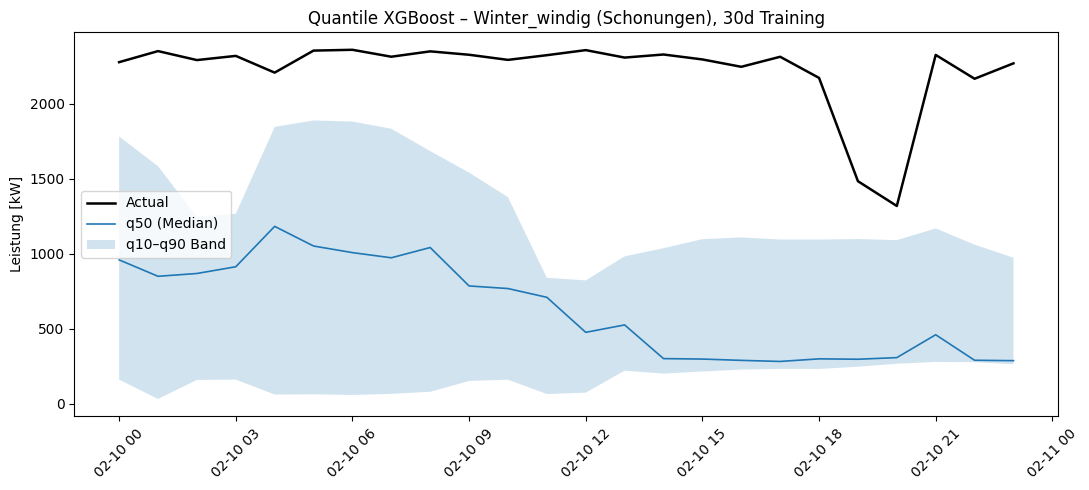

In [89]:
PLOT_DAY = "Winter_windig"
PLOT_MODEL_PREFIX = "qxgb"

PLOT_WINDOW = 30  # welches Trainingsfenster fuer den Beispiel-Plot

day_data = predictions_single_day[
    (predictions_single_day["day_label"] == PLOT_DAY) &
    (predictions_single_day["window_days"] == PLOT_WINDOW)
].sort_values("timestamp")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(day_data["timestamp"], day_data["y_true"], label="Actual", color="black", linewidth=1.8)
ax.plot(day_data["timestamp"], day_data[f"{PLOT_MODEL_PREFIX}_q50"], label="q50 (Median)", linewidth=1.2)
ax.fill_between(
    day_data["timestamp"],
    day_data[f"{PLOT_MODEL_PREFIX}_q10"],
    day_data[f"{PLOT_MODEL_PREFIX}_q90"],
    alpha=0.2, label="q10–q90 Band",
)
ax.set_title(f"Quantile XGBoost – {PLOT_DAY} ({SELECTED_PLANT}), {PLOT_WINDOW}d Training")
ax.set_ylabel("Leistung [kW]")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / f"quantile_band_{PLOT_DAY}.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Vergleich: 30 Tage vs. 90 Tage Trainingsfenster

Hintergrund: Die Zieltage wurden bewusst als windreichste bzw. windschwächste Tage ihrer Saison gewählt. Bei einem kurzen Trainingsfenster (30 Tage) enthält die Trainingshistorie oft keine vergleichbar extremen Windverhältnisse — die Modelle müssen dann außerhalb des im Training beobachteten Wertebereichs extrapolieren. Ein längeres Fenster (90 Tage) erhöht die Chance, dass auch ähnlich extreme Tage im Training enthalten sind.

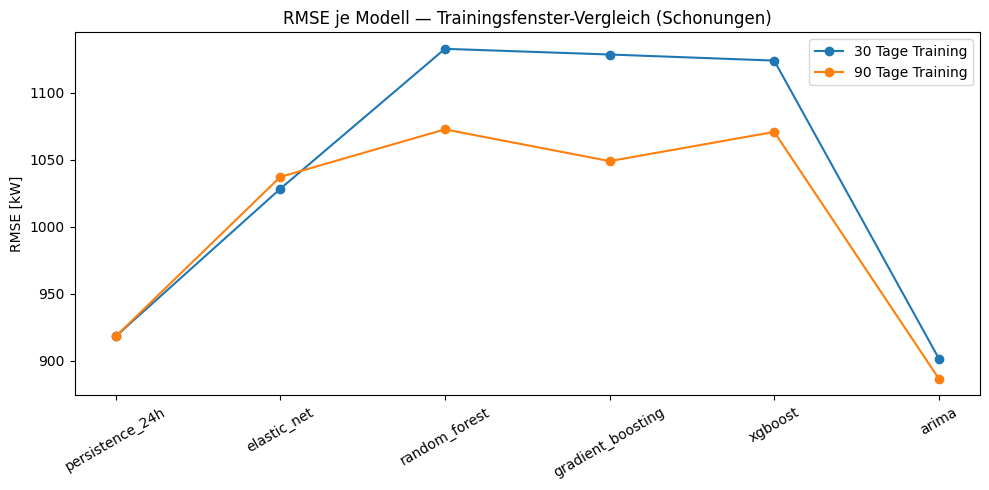

In [90]:
fig, ax = plt.subplots(figsize=(10, 5))

for window_days, grp in point_metrics_single_day.groupby("window_days"):
    grp_sorted = grp.set_index("model").reindex(POINT_MODEL_COLS)
    ax.plot(grp_sorted.index, grp_sorted["RMSE"], marker="o", label=f"{window_days} Tage Training")

ax.set_ylabel("RMSE [kW]")
ax.set_title(f"RMSE je Modell — Trainingsfenster-Vergleich ({SELECTED_PLANT})")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / "window_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Forecast vs. Actual — alle 8 Beispieltage im Überblick

Zeigt für jeden der 8 Zieltage den tatsächlichen Verlauf gegen die wichtigsten Point-Forecasts (Persistence, Elastic Net, bestes Black-Box-Modell) sowie das Quantilband eines probabilistischen Modells. So wird sichtbar, wie gut (oder schlecht) die Modelle den Tagesverlauf der Windproduktion tatsächlich treffen — nicht nur als aggregierte Fehlerzahl, sondern visuell.

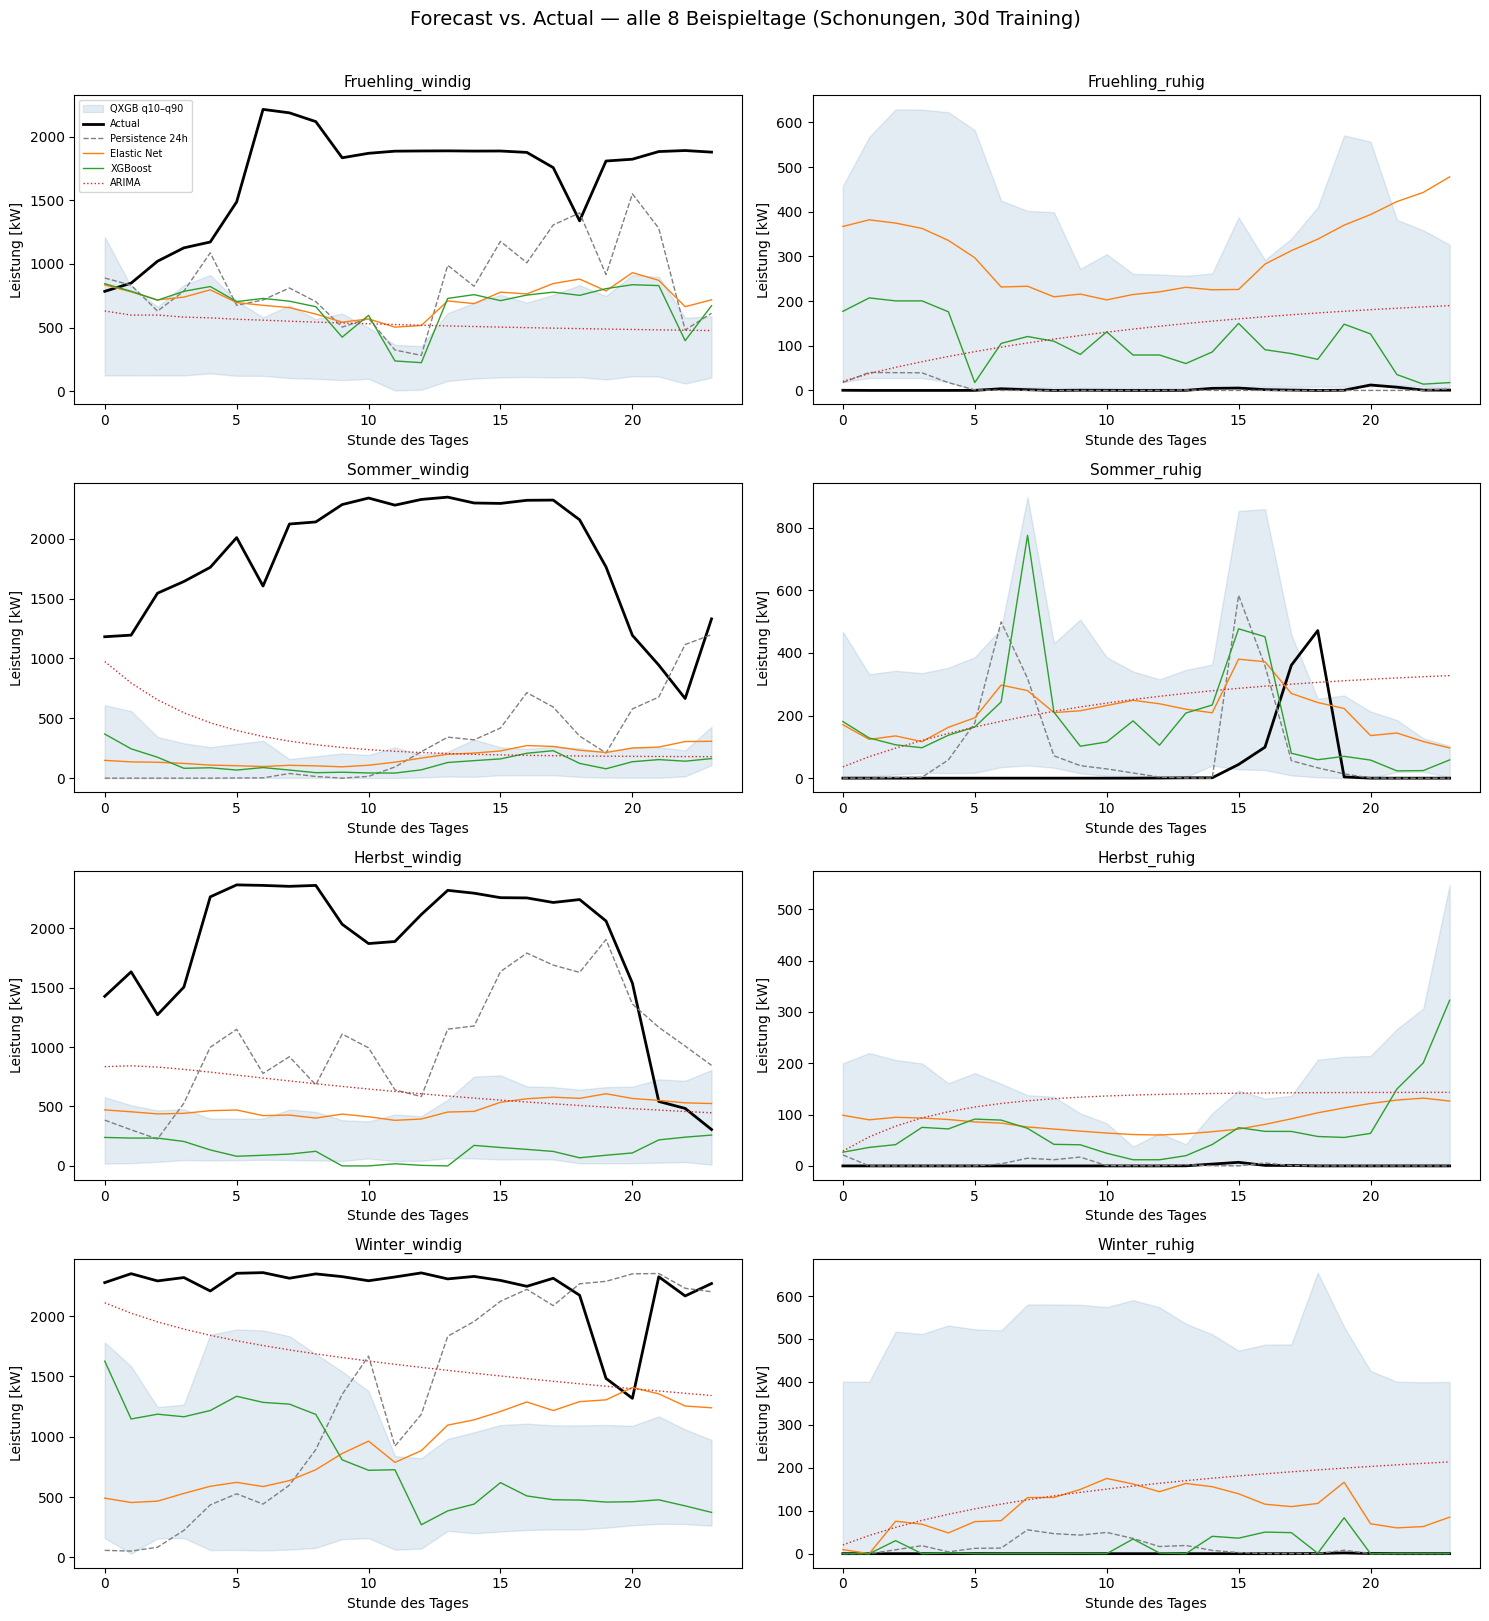

In [91]:
GRID_WINDOW = 30  # welches Trainingsfenster für die Übersichtsgrafik

day_order = list(TARGET_DAYS.keys())
n_days = len(day_order)

fig, axes = plt.subplots(4, 2, figsize=(15, 16), sharey=False)
axes = axes.flatten()

for i, day_label in enumerate(day_order):
    ax = axes[i]
    d = predictions_single_day[
        (predictions_single_day["day_label"] == day_label) &
        (predictions_single_day["window_days"] == GRID_WINDOW)
    ].sort_values("timestamp")

    if d.empty:
        ax.set_title(f"{day_label} (keine Daten)")
        continue

    hours = range(len(d))

    # Quantilband (QXGB) im Hintergrund
    ax.fill_between(hours, d["qxgb_q10"], d["qxgb_q90"], alpha=0.15, color="steelblue", label="QXGB q10–q90")

    ax.plot(hours, d["y_true"], color="black", linewidth=2, label="Actual")
    ax.plot(hours, d["persistence_24h"], color="gray", linestyle="--", linewidth=1, label="Persistence 24h")
    ax.plot(hours, d["elastic_net"], color="tab:orange", linewidth=1, label="Elastic Net")
    ax.plot(hours, d["xgboost"], color="tab:green", linewidth=1, label="XGBoost")
    ax.plot(hours, d["arima"], color="tab:red", linewidth=1, linestyle=":", label="ARIMA")

    ax.set_title(day_label, fontsize=11)
    ax.set_xlabel("Stunde des Tages")
    ax.set_ylabel("Leistung [kW]")

    if i == 0:
        ax.legend(fontsize=7, loc="upper left")

fig.suptitle(f"Forecast vs. Actual — alle 8 Beispieltage ({SELECTED_PLANT}, {GRID_WINDOW}d Training)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / f"forecast_vs_actual_grid_{GRID_WINDOW}d.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Detailvergleich: 30 vs. 90 Tage Training an einem Extremtag

Zeigt explizit, ob ein längeres Trainingsfenster die Vorhersage am windreichsten Tag des Winters verbessert — also ob das Extrapolationsproblem durch mehr Trainingsdaten gemildert wird.

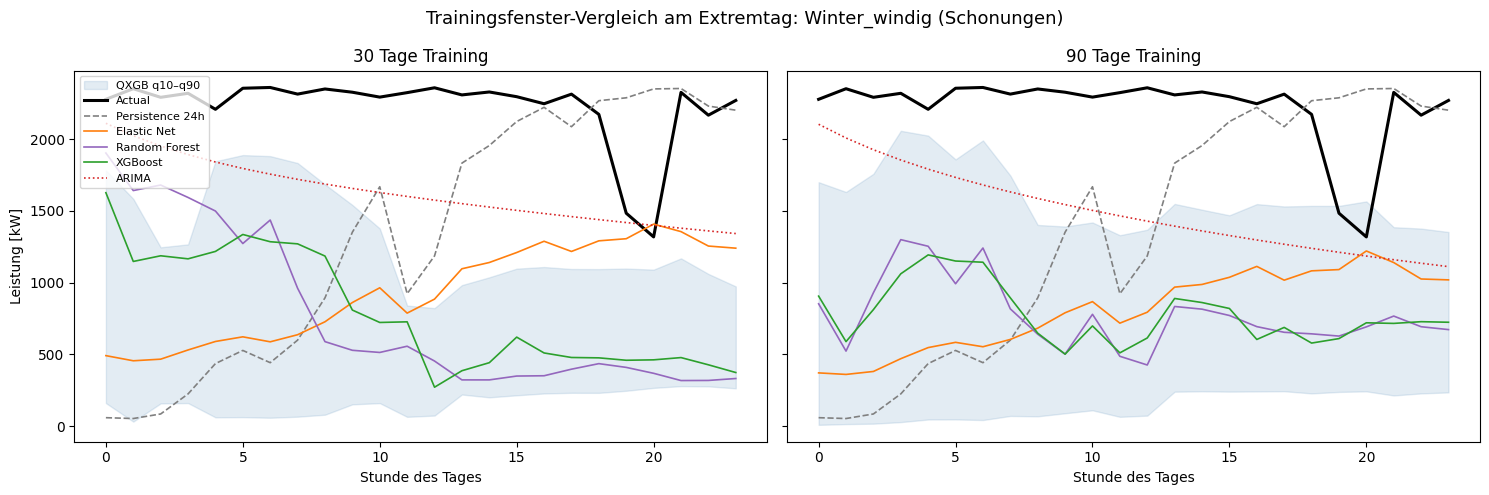

In [92]:
DETAIL_DAY = "Winter_windig"

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, window_days in zip(axes, TRAINING_WINDOW_DAYS_LIST):
    d = predictions_single_day[
        (predictions_single_day["day_label"] == DETAIL_DAY) &
        (predictions_single_day["window_days"] == window_days)
    ].sort_values("timestamp")

    hours = range(len(d))

    ax.fill_between(hours, d["qxgb_q10"], d["qxgb_q90"], alpha=0.15, color="steelblue", label="QXGB q10–q90")
    ax.plot(hours, d["y_true"], color="black", linewidth=2.2, label="Actual")
    ax.plot(hours, d["persistence_24h"], color="gray", linestyle="--", linewidth=1.2, label="Persistence 24h")
    ax.plot(hours, d["elastic_net"], color="tab:orange", linewidth=1.2, label="Elastic Net")
    ax.plot(hours, d["random_forest"], color="tab:purple", linewidth=1.2, label="Random Forest")
    ax.plot(hours, d["xgboost"], color="tab:green", linewidth=1.2, label="XGBoost")
    ax.plot(hours, d["arima"], color="tab:red", linestyle=":", linewidth=1.2, label="ARIMA")

    ax.set_title(f"{window_days} Tage Training")
    ax.set_xlabel("Stunde des Tages")

axes[0].set_ylabel("Leistung [kW]")
axes[0].legend(fontsize=8, loc="upper left")

fig.suptitle(f"Trainingsfenster-Vergleich am Extremtag: {DETAIL_DAY} ({SELECTED_PLANT})", fontsize=13)
plt.tight_layout()
plt.savefig(TABLES_DIR.parent / "figures" / f"window_detail_comparison_{DETAIL_DAY}.png", dpi=300, bbox_inches="tight")
plt.show()